# Analysis 3 — Step 4: RF/GBM 병행 + permutation importance

- **목적**: 비선형 채널효과 확인 + A1 최강 업로드변수 `tag_cnt`가 채널 추가 후 importance에서 밀려나는지 검증(Background §2-3).
- **입력**: `../Analysis1_title/LR/features_partB_v2.csv` + `step1_channel_features.csv`
- **산출**: `step4_rf_importance.csv`, `step4_fig_importance.png`

In [1]:
import numpy as np, pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
RS = 42
PRIMARY, ACCENT, GRAY = "#3B4FE4", "#1A7F5A", "#C8CDD6"

In [2]:
base = pd.read_csv("../Analysis1_title/LR/features_partB_v2.csv")
chan = pd.read_csv("step1_channel_features.csv")[["video_id", "chan_mean_oof", "chan_freq"]]
df = base.merge(chan, on="video_id", how="inner")
df["chan_freq_log"] = np.log1p(df["chan_freq"])

obj = ["title_len", "caps_ratio", "exclaim_cnt", "question_cnt", "has_number", "has_bracket", "tag_cnt"]
cat_dummies = pd.get_dummies(df[["category", "hour_bin", "publish_weekday"]].astype(str), drop_first=True)
X_content = pd.concat([df[obj], cat_dummies], axis=1)
X_chan = pd.concat([X_content, df[["chan_mean_oof", "chan_freq_log"]]], axis=1)
y = df["log_views"]
print("X_content:", X_content.shape, "| X_chan:", X_chan.shape)

X_content: (6249, 31) | X_chan: (6249, 33)


In [3]:
def fit_rf(X):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=RS)
    rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=2, random_state=RS, n_jobs=-1)
    rf.fit(Xtr, ytr)
    r2 = r2_score(yte, rf.predict(Xte))
    perm = permutation_importance(rf, Xte, yte, n_repeats=10, random_state=RS, n_jobs=-1)
    imp = (pd.DataFrame({"feature": X.columns, "perm_imp": perm.importances_mean})
           .sort_values("perm_imp", ascending=False).reset_index(drop=True))
    return r2, imp

r2_c, imp_c = fit_rf(X_content)
r2_ch, imp_ch = fit_rf(X_chan)
print(f"RF M_content      test R² = {r2_c:.4f}")
print(f"RF M_content+chan test R² = {r2_ch:.4f}   ΔR² = {r2_ch - r2_c:+.4f}")

RF M_content      test R² = 0.1115
RF M_content+chan test R² = 0.3036   ΔR² = +0.1920


In [4]:
print("M_content+chan Top10 permutation importance:")
print(imp_ch.head(10).to_string(index=False))

def rank_of(imp, f):
    r = imp.index[imp["feature"] == f]
    return int(r[0]) + 1 if len(r) else None
print(f"\ntag_cnt 순위: M_content={rank_of(imp_c,'tag_cnt')}위 → M_content+chan={rank_of(imp_ch,'tag_cnt')}위 (총 {len(imp_ch)}피처)")
print(f"chan_mean_oof={rank_of(imp_ch,'chan_mean_oof')}위, chan_freq_log={rank_of(imp_ch,'chan_freq_log')}위")
imp_ch.to_csv("step4_rf_importance.csv", index=False)
print("[저장] step4_rf_importance.csv")

M_content+chan Top10 permutation importance:
                 feature  perm_imp
           chan_mean_oof  0.525211
           chan_freq_log  0.049800
                 tag_cnt  0.014851
               title_len  0.010254
category_News & Politics  0.005759
       publish_weekday_1  0.003867
          category_Music  0.003464
              has_number  0.001947
             has_bracket  0.001563
       publish_weekday_6  0.000683

tag_cnt 순위: M_content=1위 → M_content+chan=3위 (총 33피처)
chan_mean_oof=1위, chan_freq_log=2위
[저장] step4_rf_importance.csv


[저장] step4_fig_importance.png


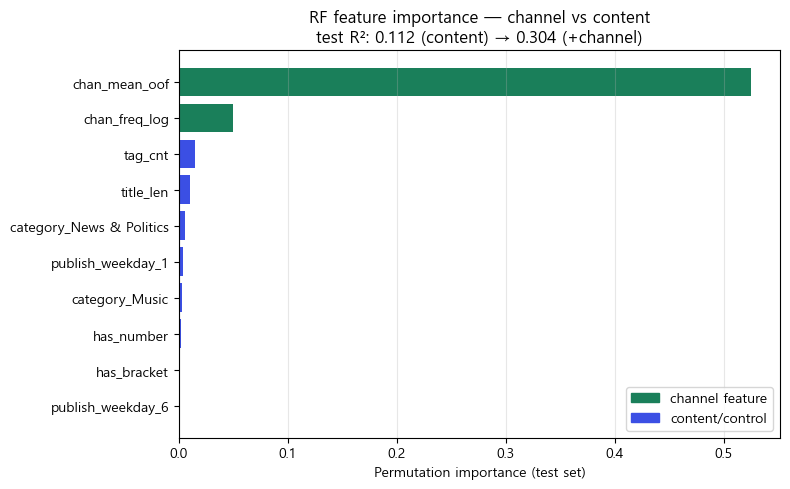

In [5]:
# 시각화 — Top10 (채널 강조)
top = imp_ch.head(10).iloc[::-1]
colors = [ACCENT if f.startswith("chan_") else PRIMARY for f in top["feature"]]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top["feature"], top["perm_imp"], color=colors)
ax.set_xlabel("Permutation importance (test set)")
ax.set_title(f"RF feature importance — channel vs content\ntest R²: {r2_c:.3f} (content) → {r2_ch:.3f} (+channel)")
ax.grid(axis="x", alpha=0.3)
handles = [plt.Rectangle((0,0),1,1,color=ACCENT), plt.Rectangle((0,0),1,1,color=PRIMARY)]
ax.legend(handles, ["channel feature", "content/control"], loc="lower right")
fig.tight_layout()
fig.savefig("step4_fig_importance.png", dpi=200)
print("[저장] step4_fig_importance.png")
plt.show()

## 점검 메모

- RF ΔR²=+0.192 (LR과 일관 → 채널효과는 주로 선형).
- **chan_mean_oof 1위(압도) > chan_freq_log 2위 > tag_cnt 3위**.
- **tag_cnt: M_content 1위 → +channel 3위** → A1 최강 업로드변수가 채널 뒤로 밀림 = "tag_cnt는 채널 프록시" 직접 입증.